# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [ ]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


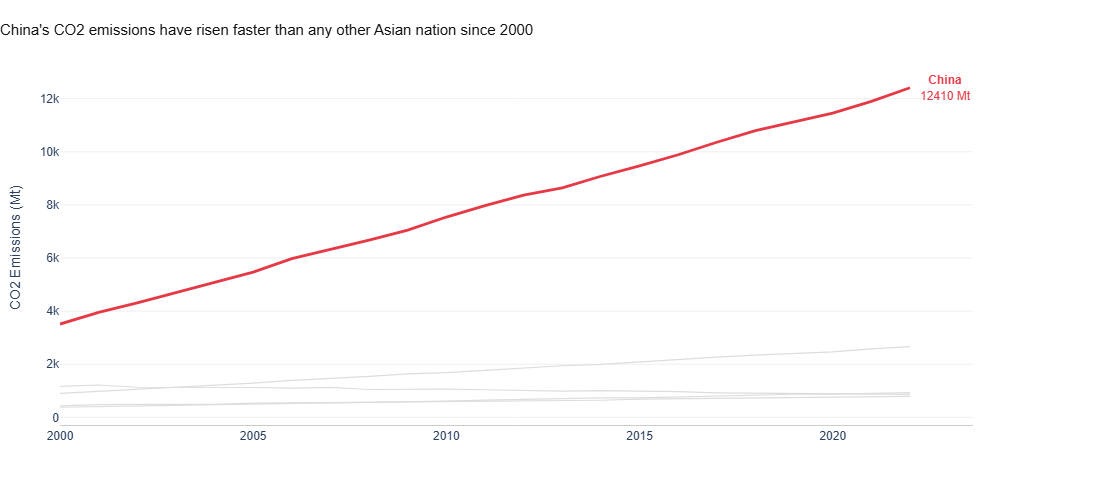

In [4]:
HIGHLIGHT_COUNTRY = "China"
HIGHLIGHT_COLOR = "#E63946"
GREY = "#DDDDDD"

asia_df = df[df["Region"] == "Asia"].copy()
countries = asia_df["Country"].unique()

fig = go.Figure()
 
# Grey context lines
for country in countries:
    if country == HIGHLIGHT_COUNTRY:
        continue
 
    cdf = asia_df[asia_df["Country"] == country].sort_values("Year")
 
    fig.add_trace(
        go.Scatter(
            x=cdf["Year"],
            y=cdf["CO2_Mt"],
            mode="lines",
            line=dict(color=GREY, width=1.2),
            showlegend=False,
            hovertemplate=f"{country}: %{{y:.0f}} Mt<extra></extra>",
        )
    )
 
# Highlighted line
hdf = asia_df[asia_df["Country"] == HIGHLIGHT_COUNTRY].sort_values("Year")
 
fig.add_trace(
    go.Scatter(
        x=hdf["Year"],
        y=hdf["CO2_Mt"],
        mode="lines",
        line=dict(color=HIGHLIGHT_COLOR, width=2.8),
        showlegend=False,
        hovertemplate=f"{HIGHLIGHT_COUNTRY}: %{{y:.0f}} Mt<extra></extra>",
    )
)
 
last_row = hdf.iloc[-1]
fig.add_annotation(
    x=last_row["Year"],
    y=last_row["CO2_Mt"],
    text=f"<b>{HIGHLIGHT_COUNTRY}</b><br>{last_row['CO2_Mt']:.0f} Mt",
    showarrow=False,
    xanchor="left",
    xshift=8,
    font=dict(color=HIGHLIGHT_COLOR, size=12, family="Arial"),
)
 
fig.update_layout(
    title=dict(
        text="China's CO2 emissions have risen faster than any other Asian nation since 2000",
        x=0,
        xanchor="left",
        font=dict(size=15, family="Arial", color="#111111"),
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial"),
    xaxis=dict(
        showgrid=False,
        showline=True,
        linecolor="#CCCCCC",
        title="",
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#F0F0F0",
        showline=False,
        zeroline=False,
        title="CO2 Emissions (Mt)",
    ),
    margin=dict(l=60, r=120, t=70, b=50),
    height=480,
)


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


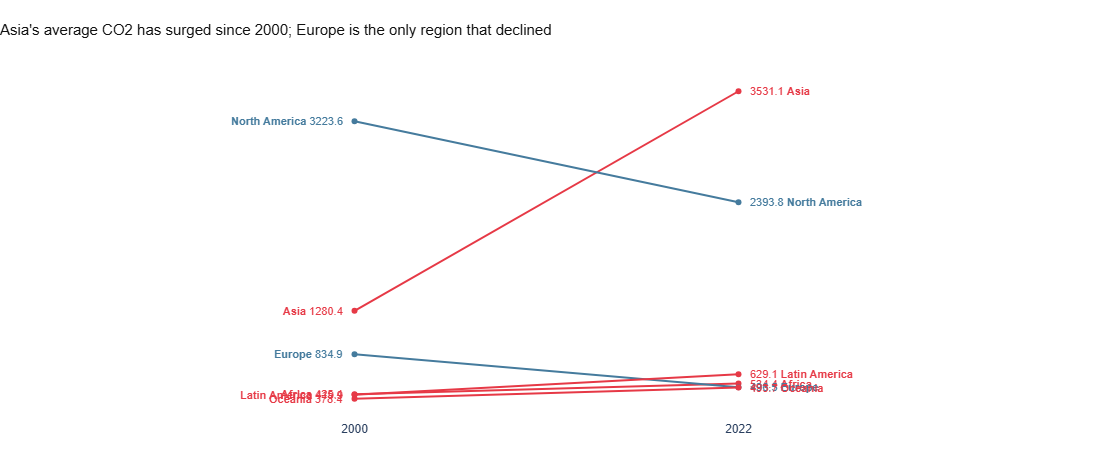

In [5]:
COLOR_INCREASE = "#E63946"
COLOR_DECREASE = "#457B9D"
 
regional = (
    df.groupby(["Region", "Year"])["CO2_Mt"]
    .mean()
    .reset_index()
)
 
slope_df = regional[regional["Year"].isin([2000, 2022])].copy()
 
pivot = slope_df.pivot(index="Region", columns="Year", values="CO2_Mt").reset_index()
pivot.columns = ["Region", "y2000", "y2022"]
pivot["increased"] = pivot["y2022"] > pivot["y2000"]
 
fig = go.Figure()
 
for _, row in pivot.iterrows():
    color = COLOR_INCREASE if row["increased"] else COLOR_DECREASE
    region = row["Region"]
 
    fig.add_trace(
        go.Scatter(
            x=[2000, 2022],
            y=[row["y2000"], row["y2022"]],
            mode="lines+markers",
            line=dict(color=color, width=2),
            marker=dict(size=6, color=color),
            showlegend=False,
            hovertemplate=f"{region}<br>%{{x}}: %{{y:.1f}} Mt<extra></extra>",
        )
    )
 
    fig.add_annotation(
        x=2000,
        y=row["y2000"],
        text=f"<b>{region}</b> {row['y2000']:.1f}",
        showarrow=False,
        xanchor="right",
        xshift=-10,
        font=dict(size=11, color=color, family="Arial"),
    )
 
    fig.add_annotation(
        x=2022,
        y=row["y2022"],
        text=f"{row['y2022']:.1f} <b>{region}</b>",
        showarrow=False,
        xanchor="left",
        xshift=10,
        font=dict(size=11, color=color, family="Arial"),
    )
 
fig.update_layout(
    title=dict(
        text="Asia's average CO2 has surged since 2000; Europe is the only region that declined",
        x=0,
        xanchor="left",
        font=dict(size=15, family="Arial", color="#111111"),
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial"),
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=["2000", "2022"],
        showgrid=False,
        showline=False,
        range=[1990, 2032],
    ),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        showline=False,
        zeroline=False,
    ),
    margin=dict(l=180, r=180, t=70, b=40),
    height=460,
)
 
fig.show()
